In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as datetime
from scipy.stats import norm


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/local/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/local/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/site-packages/ipykernel

AttributeError: _ARRAY_API not found

/tmp/ipykernel_15376/3303972676.py:1: DtypeWarning: Columns (7,9,11,13,15,17,29,37,39,41,43,45,47,49,51,53,55,57,77,79,81,85,89,93,95,97) have mixed types. Specify dtype option on import or set low_memory=False.
  dsm = pd.read_csv('DSM_IA_Weather.csv')


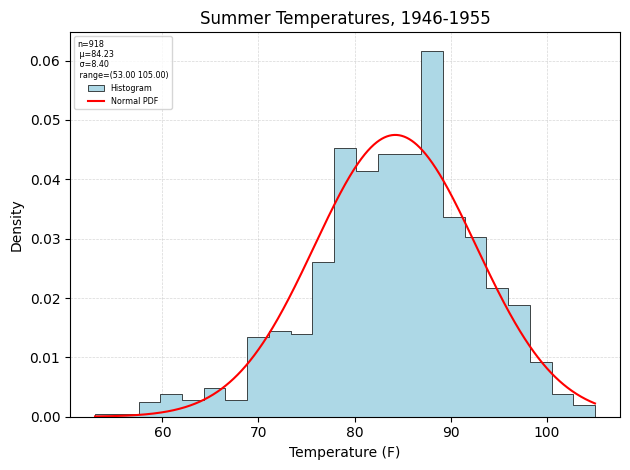

In [37]:
dsm = pd.read_csv('DSM_IA_Weather.csv')
dsm_1 = dsm.loc[:,['NAME','DATE','TMAX']]
dsm_1['DATE'] = pd.to_datetime(dsm_1['DATE'], format="%Y-%m-%d")
dsm_1['year'] = dsm_1['DATE'].dt.year
dsm_1['month'] = dsm_1['DATE'].dt.month
dsm_1['day'] = dsm_1['DATE'].dt.day

decades = {"46_55":list(range(1946,1956)),
           "56_65":list(range(1956,1966)),
           "66_75":list(range(1966,1976)),
           "76_85":list(range(1976,1986)),
           "86_95":list(range(1986,1996)),
           "96_05":list(range(1996,2005)),
           "06_15":list(range(2006,2016)),
           "16_25":list(range(2016,2026))}

t_45_55_temp = dsm_1[(dsm_1.year.isin(decades["46_55"])) & (dsm_1.month.isin([6,7,8]))]

t_45_55 = t_45_55_temp[['DATE','TMAX']]
t_45_55_temps = list(t_45_55.TMAX)

n = len(t_45_55_temps)
x_bar_45_55 = sum(t_45_55_temps)/len(t_45_55_temps)
s_45_55 = float(np.std(t_45_55_temps,ddof=1))
range_45_55 = (min(t_45_55_temps),max(t_45_55_temps))

fig,ax = plt.subplots()

ax.hist(t_45_55_temps,bins='fd',density=True,histtype='stepfilled',alpha=1,label="Histogram",color='lightblue',edgecolor='black',linewidth=.5,zorder=2)
x = np.linspace(min(t_45_55_temps),max(t_45_55_temps),1000)
pdf_values_1 = norm.pdf(x,loc=x_bar_45_55,scale=s_45_55)
ax.plot(x, pdf_values_1,color='red',linewidth=1.5,label="Normal PDF",zorder=3)

ax.set_xlabel("Temperature (F)")
ax.set_ylabel("Density")
ax.set_title("Summer Temperatures, 1946-1955")
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5,zorder=1)

stats_text = f"n={n}\n μ={x_bar_45_55:.2f}\n σ={s_45_55:.2f}\n range=({range_45_55[0]:.2f} {range_45_55[1]:.2f})"
ax.legend(title=stats_text, loc="upper left",fontsize='xx-small',title_fontsize='xx-small')

plt.tight_layout()

plt.show()

In [43]:
del range

dsm = pd.read_csv('DSM_IA_Weather.csv')
dsm_1 = dsm.loc[:,['NAME','DATE','TMAX']]
dsm_1['DATE'] = pd.to_datetime(dsm_1['DATE'], format="%Y-%m-%d")
dsm_1['year'] = dsm_1['DATE'].dt.year
dsm_1['month'] = dsm_1['DATE'].dt.month
dsm_1['day'] = dsm_1['DATE'].dt.day

decades = {"46_55":list(range(1946,1956)),
           "56_65":list(range(1956,1966)),
           "66_75":list(range(1966,1976)),
           "76_85":list(range(1976,1986)),
           "86_95":list(range(1986,1996)),
           "96_05":list(range(1996,2005)),
           "06_15":list(range(2006,2016)),
           "16_25":list(range(2016,2026))}


for decade_name, years in decades.items():
    df_decade = dsm_1[(dsm_1.year.isin(years)) & (dsm_1.month.isin([6,7,8]))]
    temps = df_decade['TMAX'].tolist()

    n = len(temps)
    x_bar = sum(temps)/len(temps)
    s = float(np.std(temps,ddof=1))
    range = (min(temps),max(temps))

    fig,ax = plt.subplots()
    
    ax.hist(l,bins='fd',density=True,histtype='stepfilled',alpha=1,label="Histogram",color='lightblue',edgecolor='black',linewidth=.5,zorder=2)
    x = np.linspace(min(l),max(l),1000)
    pdf_values_1 = norm.pdf(x,loc=x_bar,scale=s)
    ax.plot(x, pdf_values_1,color='red',linewidth=1.5,label="Normal PDF",zorder=3)
    
    ax.set_xlabel("Temperature (F)")
    ax.set_ylabel("Density")
    ax.set_title(f"Summer Temperatures, {i}")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5,zorder=1)
    
    stats_text = f"n={n}\n μ={x_bar:.2f}\n σ={s:.2f}\n range=({range[0]:.2f} {range[1]:.2f})"
    ax.legend(title=stats_text, loc="upper left",fontsize='xx-small',title_fontsize='xx-small')
    
    plt.tight_layout()
    
    plt.show()

/tmp/ipykernel_15376/3449561468.py:1: DtypeWarning: Columns (7,9,11,13,15,17,29,37,39,41,43,45,47,49,51,53,55,57,77,79,81,85,89,93,95,97) have mixed types. Specify dtype option on import or set low_memory=False.
  dsm = pd.read_csv('DSM_IA_Weather.csv')


TypeError: 'tuple' object is not callable

/tmp/ipykernel_15376/725486954.py:11: DtypeWarning: Columns (7,9,11,13,15,17,29,37,39,41,43,45,47,49,51,53,55,57,77,79,81,85,89,93,95,97) have mixed types. Specify dtype option on import or set low_memory=False.
  dsm = pd.read_csv('DSM_IA_Weather.csv')


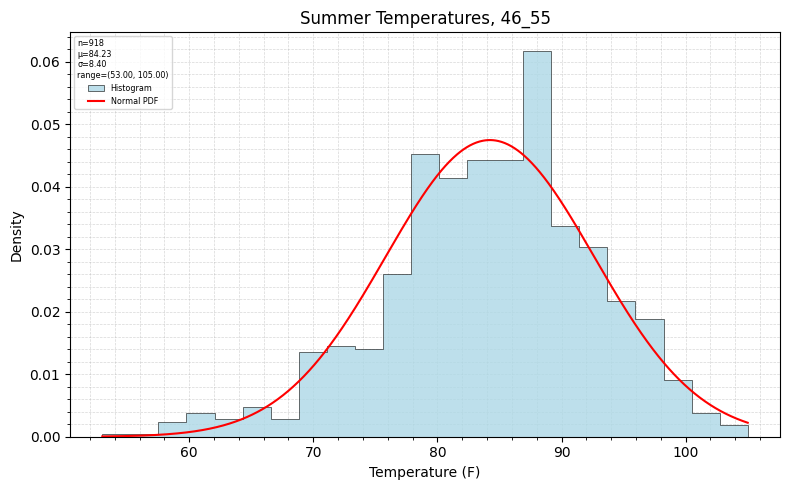

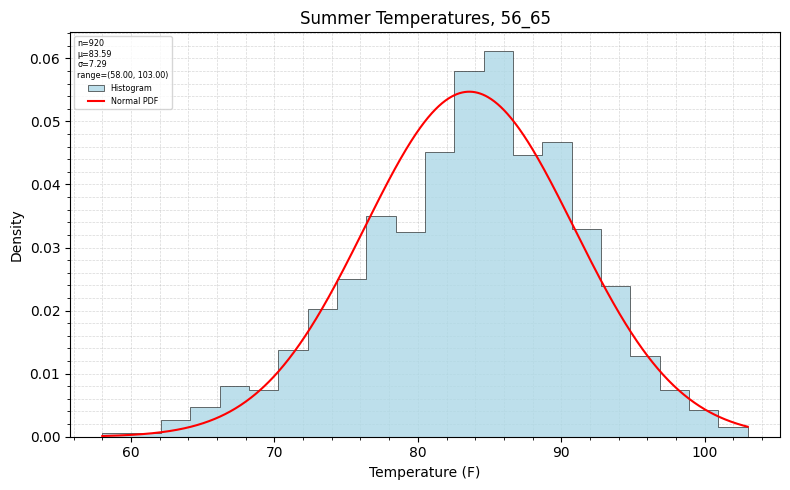

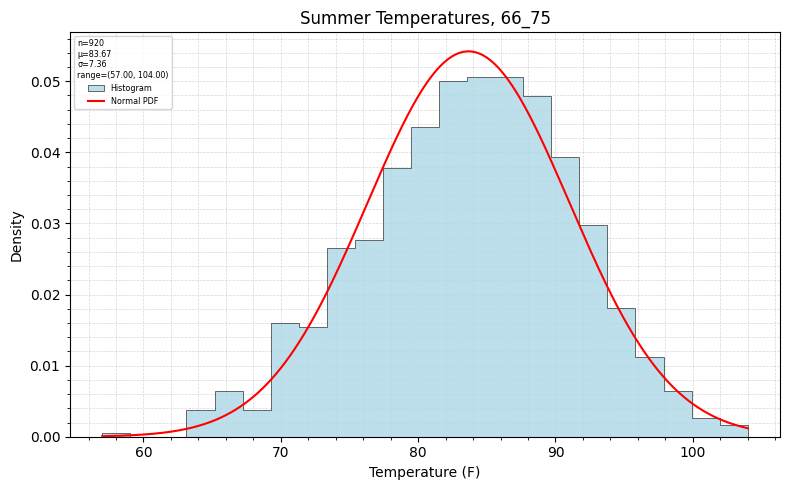

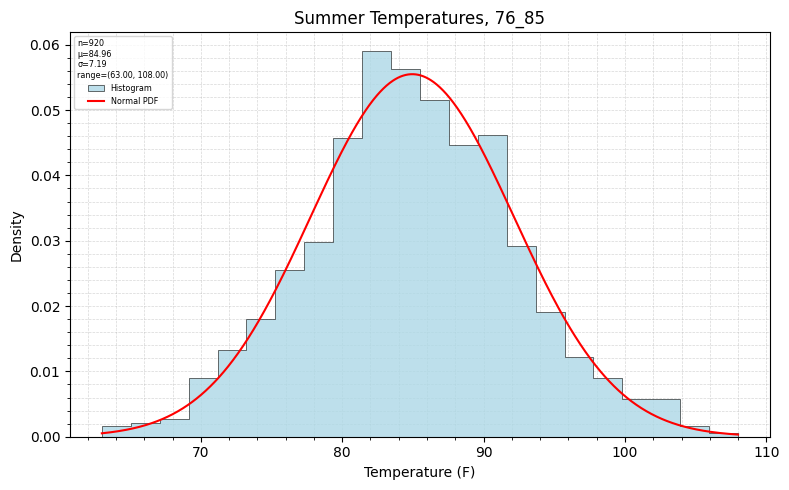

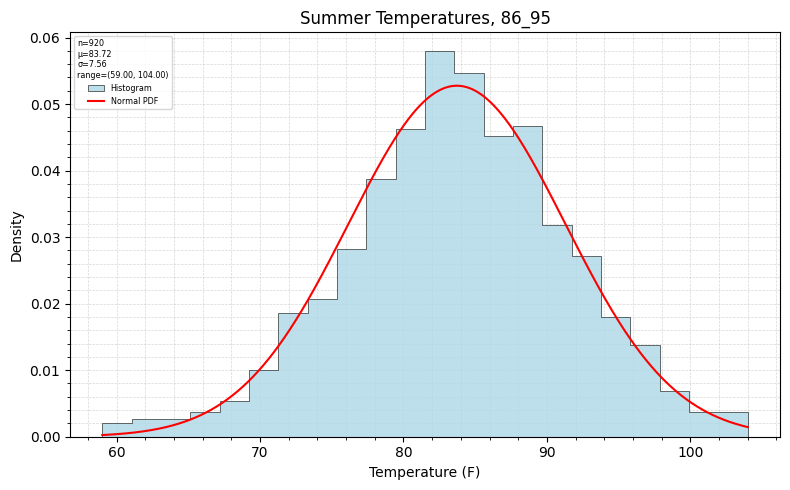

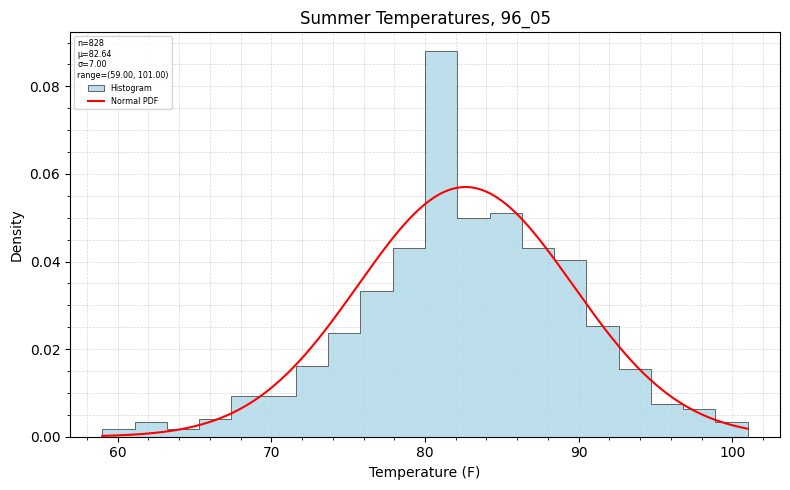

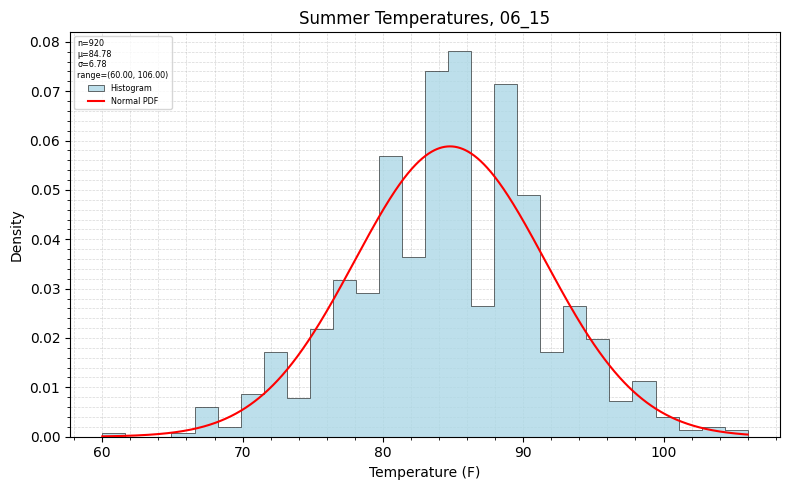

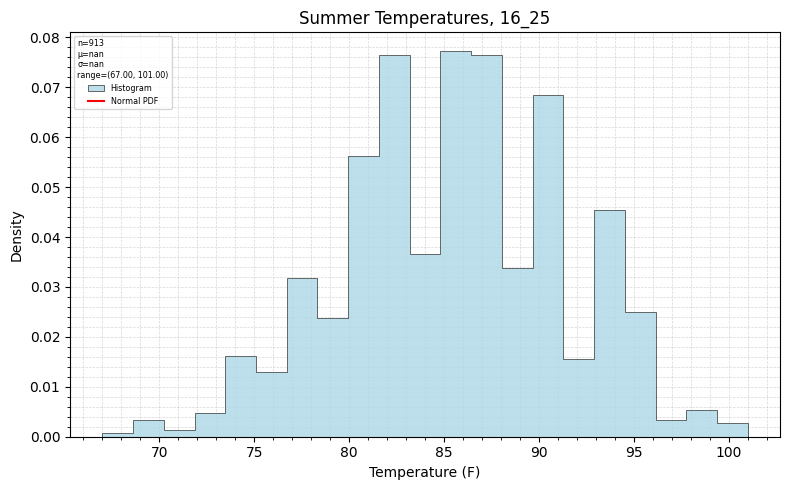

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Restore built-in range and list in case they were overwritten
#del range
#del list

# Load data
dsm = pd.read_csv('DSM_IA_Weather.csv')
dsm_1 = dsm.loc[:, ['NAME','DATE','TMAX']]
dsm_1['DATE'] = pd.to_datetime(dsm_1['DATE'], format="%Y-%m-%d")
dsm_1['year'] = dsm_1['DATE'].dt.year
dsm_1['month'] = dsm_1['DATE'].dt.month

# Define decades
decades = {
    "46_55": list(range(1946, 1956)),
    "56_65": list(range(1956, 1966)),
    "66_75": list(range(1966, 1976)),
    "76_85": list(range(1976, 1986)),
    "86_95": list(range(1986, 1996)),
    "96_05": list(range(1996, 2005)),
    "06_15": list(range(2006, 2016)),
    "16_25": list(range(2016, 2026))
}

# Iterate through each decade
for decade_name, years in decades.items():
    # Filter for summer months
    df_decade = dsm_1[(dsm_1.year.isin(years)) & (dsm_1.month.isin([6,7,8]))]
    temps = df_decade['TMAX'].tolist()
    
    if len(temps) == 0:
        print(f"No data for decade {decade_name}, skipping.")
        continue
    
    # Calculate stats
    n = len(temps)
    mean = np.mean(temps)
    sigma = float(np.std(temps, ddof=1))
    temp_range = (min(temps), max(temps))
    
    stats_text = f"n={n}\nμ={mean:.2f}\nσ={sigma:.2f}\nrange=({temp_range[0]:.2f}, {temp_range[1]:.2f})"
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8,5))
    
    # Histogram
    ax.hist(temps, bins='fd', density=True, histtype='stepfilled',
            alpha=0.8, color='lightblue', edgecolor='black', linewidth=0.5, zorder=2,label="Histogram")
    
    # Normal PDF
    x = np.linspace(min(temps), max(temps), 1000)
    pdf_values = norm.pdf(x, loc=mean, scale=sigma)
    ax.plot(x, pdf_values, color='red', linewidth=1.5, label="Normal PDF", zorder=3)
    
    # Labels and title
    ax.set_xlabel("Temperature (F)")
    ax.set_ylabel("Density")
    ax.set_title(f"Summer Temperatures, {decade_name}")
    
    # Gridlines behind the data
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax.minorticks_on()
    
    # Legend with stats
    ax.legend(title=stats_text, loc="upper left", fontsize='xx-small', title_fontsize='xx-small')
    
    plt.tight_layout()
    plt.show()

In [60]:
import pandas as pd
import numpy as np

# Prepare an empty list to store stats


summary_list = []

for decade_name, years in decades.items():
    # Filter summer months for the decade
    df_decade = dsm_1[(dsm_1.year.isin(years)) & (dsm_1.month.isin([6,7,8]))]
    temps = df_decade['TMAX'].dropna().astype(float).tolist()
    
    
    if len(temps) == 0:
        # Skip decades with no data
        continue
    
    n = len(temps)
    mean = np.mean(temps)
    sigma = float(np.std(temps, ddof=1))
    temp_range = (min(temps), max(temps))
    std_error = sigma / np.sqrt(n)  # standard error
    
    # Append dictionary of stats to the list
    summary_list.append({
        "Decade": decade_name,
        "n": n,
        "Mean": mean,
        "Sigma": sigma,
        "Range": f"({temp_range[0]:.2f}, {temp_range[1]:.2f})",
        "Std_Error": std_error
    })

# Convert list of dicts to DataFrame
summary_df = pd.DataFrame(summary_list)

# Optional: sort by decade
decade_order = ["46_55","56_65","66_75","76_85","86_95","96_05","06_15","16_25"]
summary_df['Decade'] = pd.Categorical(summary_df['Decade'], categories=decade_order, ordered=True)
summary_df = summary_df.sort_values("Decade").reset_index(drop=True)

summary_df

,Decade,n,Mean,Sigma,Range,Std_Error
0,46_55,918,84.227669,8.403368,"(53.00, 105.00)",0.277352
1,56_65,920,83.589130,7.291736,"(58.00, 103.00)",0.240401
2,66_75,920,83.667391,7.359139,"(57.00, 104.00)",0.242624
3,76_85,920,84.955435,7.189581,"(63.00, 108.00)",0.237033
4,86_95,920,83.721739,7.562346,"(59.00, 104.00)",0.249323
5,96_05,828,82.635266,6.997655,"(59.00, 101.00)",0.243185
6,06_15,920,84.777174,6.782436,"(60.00, 106.00)",0.223610
7,16_25,912,85.571272,5.802585,"(67.00, 101.00)",0.192143


In [61]:
periods_5yr = {
    "46_50": list(range(1946, 1951)),
    "51_55": list(range(1951, 1956)),
    "56_60": list(range(1956, 1961)),
    "61_65": list(range(1961, 1966)),
    "66_70": list(range(1966, 1971)),
    "71_75": list(range(1971, 1976)),
    "76_80": list(range(1976, 1981)),
    "81_85": list(range(1981, 1986)),
    "86_90": list(range(1986, 1991)),
    "91_95": list(range(1991, 1996)),
    "96_00": list(range(1996, 2001)),
    "01_05": list(range(2001, 2006)),
    "06_10": list(range(2006, 2011)),
    "11_15": list(range(2011, 2016)),
    "16_20": list(range(2016, 2021)),
    "21_25": list(range(2021, 2026))
}


summary_list = []

for p_name, years in periods_5yr.items():
    # Filter summer months for the decade
    df_p = dsm_1[(dsm_1.year.isin(years)) & (dsm_1.month.isin([6,7,8]))]
    temps = df_p['TMAX'].dropna().astype(float).tolist()
    
    
    if len(temps) == 0:
        # Skip decades with no data
        continue
    
    n = len(temps)
    mean = np.mean(temps)
    sigma = float(np.std(temps, ddof=1))
    temp_range = (min(temps), max(temps))
    std_error = sigma / np.sqrt(n)  # standard error
    
    # Append dictionary of stats to the list
    summary_list.append({
        "Timeframe": p_name,
        "n": n,
        "Mean": mean,
        "Sigma": sigma,
        "Range": f"({temp_range[0]:.2f}, {temp_range[1]:.2f})",
        "Std_Error": std_error
    })

# Convert list of dicts to DataFrame
summary_df = pd.DataFrame(summary_list)

# Optional: sort by decade
time_p_order = ["46_50","51_55","56_60","61_65","66_70","71_75","76_80","81_85","86_90","91_95","96_00","01_05","06_10","11_15","16_20","21_25"]
summary_df['Timeframe'] = pd.Categorical(summary_df['Timeframe'], categories=time_p_order, ordered=True)
summary_df = summary_df.sort_values("Timeframe").reset_index(drop=True)

summary_df

,Timeframe,n,Mean,Sigma,Range,Std_Error
0,46_50,458,83.467249,8.320443,"(53.00, 102.00)",0.388789
1,51_55,460,84.984783,8.426136,"(57.00, 105.00)",0.392871
2,56_60,460,84.128261,7.647380,"(62.00, 103.00)",0.356561
3,61_65,460,83.050000,6.884014,"(58.00, 100.00)",0.320969
4,66_70,460,82.895652,7.209439,"(57.00, 100.00)",0.336142
5,71_75,460,84.439130,7.433847,"(64.00, 104.00)",0.346605
6,76_80,460,85.102174,6.852984,"(63.00, 103.00)",0.319522
7,81_85,460,84.808696,7.515730,"(63.00, 108.00)",0.350423
8,86_90,460,84.732609,7.929168,"(61.00, 104.00)",0.369699
9,91_95,460,82.710870,7.041512,"(59.00, 101.00)",0.328312


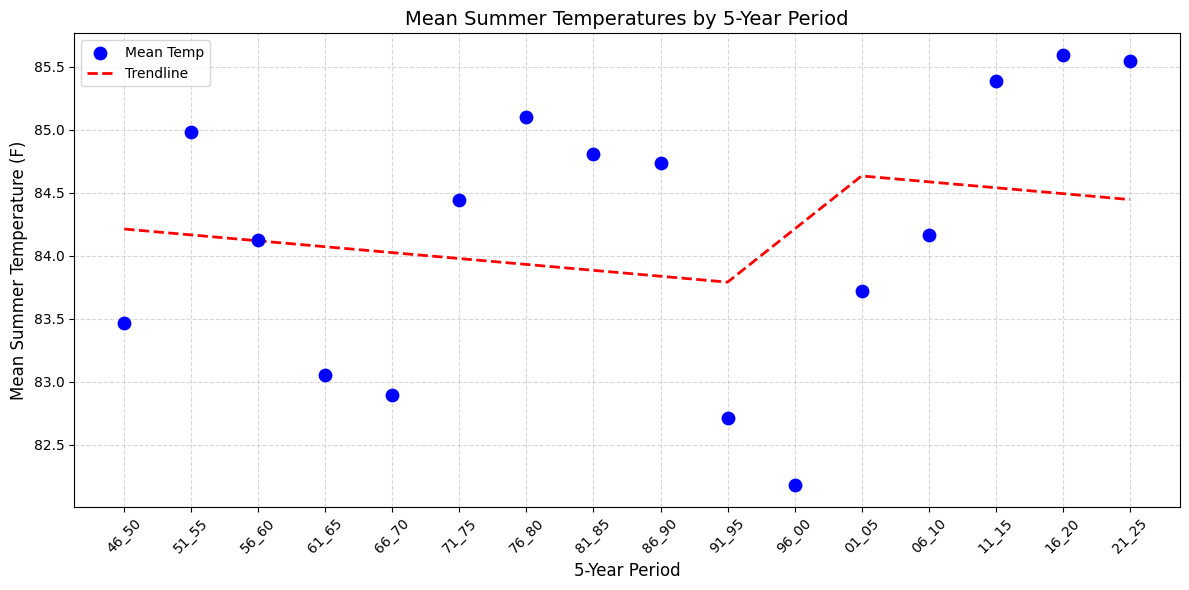

In [70]:
# Ensure Timeframe is ordered
time_p_order = ["46_50","51_55","56_60","61_65","66_70","71_75","76_80","81_85",
                "86_90","91_95","96_00","01_05","06_10","11_15","16_20","21_25"]

summary_df['Timeframe'] = pd.Categorical(summary_df['Timeframe'],
                                         categories=time_p_order, ordered=True)
summary_df = summary_df.sort_values('Timeframe').reset_index(drop=True)

# X positions (0, 1, 2, …)
x_pos = np.arange(len(summary_df))

# Numeric midpoints for trendline calculation
mid_year = summary_df['Timeframe'].apply(lambda x: (int(x.split('_')[0]) + int(x.split('_')[1])) / 2)

plt.figure(figsize=(12,6))

# Scatter plot
plt.scatter(x_pos, summary_df['Mean'], color='blue', s=80, label='Mean Temp', zorder=3)

# Trendline using numeric midpoints but plotted at x positions
coeffs = np.polyfit(mid_year, summary_df['Mean'], deg=1)
trendline = np.poly1d(coeffs)
plt.plot(x_pos, trendline(mid_year), color='red', linestyle='--', linewidth=2, label='Trendline', zorder=2)

# X-axis ticks and labels
plt.xticks(x_pos, summary_df['Timeframe'], rotation=45)

# Labels, title, legend
plt.xlabel('5-Year Period', fontsize=12)
plt.ylabel('Mean Summer Temperature (F)', fontsize=12)
plt.title('Mean Summer Temperatures by 5-Year Period', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)
plt.tight_layout()
plt.show()

In [71]:
df_2 = pd.read_csv('DSM_IA_Weather.csv')

/tmp/ipykernel_15376/2780853565.py:1: DtypeWarning: Columns (7,9,11,13,15,17,29,37,39,41,43,45,47,49,51,53,55,57,77,79,81,85,89,93,95,97) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2 = pd.read_csv('DSM_IA_Weather.csv')


In [72]:
df_2.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,ACMH,ACMH_ATTRIBUTES,ACSH,ACSH_ATTRIBUTES,...,WT17,WT17_ATTRIBUTES,WT18,WT18_ATTRIBUTES,WT19,WT19_ATTRIBUTES,WT21,WT21_ATTRIBUTES,WT22,WT22_ATTRIBUTES
0,USW00014933,"DES MOINES INTERNATIONAL AIRPORT, IA US",41.53395,-93.65313,286.3,1945-07-01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00014933,"DES MOINES INTERNATIONAL AIRPORT, IA US",41.53395,-93.65313,286.3,1945-07-02,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00014933,"DES MOINES INTERNATIONAL AIRPORT, IA US",41.53395,-93.65313,286.3,1945-07-03,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00014933,"DES MOINES INTERNATIONAL AIRPORT, IA US",41.53395,-93.65313,286.3,1945-07-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00014933,"DES MOINES INTERNATIONAL AIRPORT, IA US",41.53395,-93.65313,286.3,1945-07-05,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
df_3 = df_2[['DATE','TMAX']]
df_3

,DATE,TMAX
0,1945-07-01,71.0
1,1945-07-02,76.0
2,1945-07-03,81.0
3,1945-07-04,88.0
4,1945-07-05,78.0
...,...,...
29263,2025-08-20,87.0
29264,2025-08-21,82.0
29265,2025-08-22,83.0
29266,2025-08-23,77.0


In [74]:
df_4 = df_3.sample(n=150)

In [75]:
df_4

,DATE,TMAX
7336,1965-08-08,81.0
3761,1955-10-25,77.0
6995,1964-09-01,82.0
16369,1990-05-02,66.0
16861,1991-09-06,88.0
...,...,...
14353,1984-10-24,56.0
27718,2021-05-28,50.0
17349,1993-01-06,21.0
18127,1995-02-23,47.0


#### demonstrating the central limit theorem by taking taking 10,000 samples of size n=300 from daily temperatures in DMS,IA from 1945-2025, calculating the mean of each of the samples, then plotting. population data takes a bimodal distribution (winter/summer), but sample means form a normal distribution

/tmp/ipykernel_15376/1841616665.py:5: DtypeWarning: Columns (7,9,11,13,15,17,29,37,39,41,43,45,47,49,51,53,55,57,77,79,81,85,89,93,95,97) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2 = pd.read_csv('DSM_IA_Weather.csv')


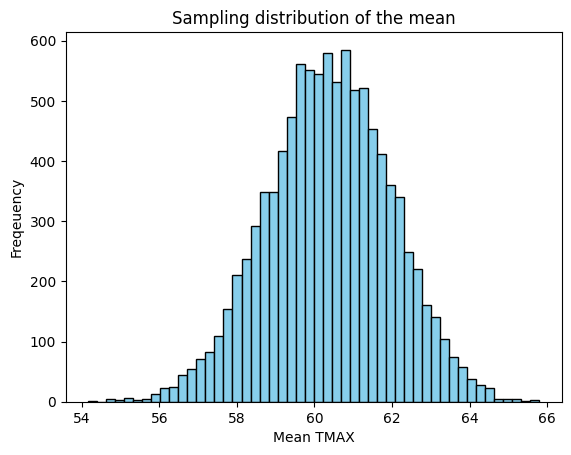

average mean of 10000 samples: 60.3716
average sigma of samples: 22.7348
mean of population: 60.3739
sigma of pop: 22.7504
average standard error of sample: 1.6076


In [110]:
import statistics
import math
import matplotlib.pyplot as plt

df_2 = pd.read_csv('DSM_IA_Weather.csv')
df_3 = df_2[['DATE','TMAX']]

population_mean = df_3.TMAX.mean()
population_sigma = df_3.TMAX.std()

sample_means = []
sample_sigmas = []
standard_errors = []

for i in range(10000):
    df = df_3.sample(n=200)
    sample_means.append(df.TMAX.mean())
    sample_sigmas.append(df.TMAX.std())
    standard_errors.append(df.TMAX.std()/math.sqrt(200))

mean_of_samples = sum(sample_means)/len(sample_means)
mean_of_sample_sigmas = sum(sample_sigmas)/len(sample_sigmas)
mean_of_standard_errors = sum(standard_errors)/len(standard_errors)

plt.hist(sample_means,bins=50, color='skyblue', edgecolor='black')
plt.title("Sampling distribution of the mean")
plt.xlabel("Mean TMAX")
plt.ylabel("Freqeuency")
plt.show()
print(f"average mean of 10000 samples: {mean_of_samples:.4f}")
print(f"average sigma of samples: {mean_of_sample_sigmas:.4f}")
print(f"mean of population: {population_mean:.4f}")
print(f"sigma of pop: {population_sigma:.4f}")
print(f"average standard error of sample: {mean_of_standard_errors:.4f}")


In [81]:
df_3.size

58536

In [82]:
df_3.info

<bound method DataFrame.info of              DATE  TMAX
0      1945-07-01  71.0
1      1945-07-02  76.0
2      1945-07-03  81.0
3      1945-07-04  88.0
4      1945-07-05  78.0
...           ...   ...
29263  2025-08-20  87.0
29264  2025-08-21  82.0
29265  2025-08-22  83.0
29266  2025-08-23  77.0
29267  2025-08-24   NaN

[29268 rows x 2 columns]>

In [84]:
df_3.TMAX.mean()

np.float64(60.373893729711256)

#### demonstrating the central limit theorem by taking taking 10,000 samples of size n=300 from daily temperatures in DMS,IA from 1945-2025, calculating the mean of each of the samples, then plotting. population data takes a bimodal distribution (winter/summer), but sample means form a normal distribution

/tmp/ipykernel_15376/2846438560.py:5: DtypeWarning: Columns (7,9,11,13,15,17,29,37,39,41,43,45,47,49,51,53,55,57,77,79,81,85,89,93,95,97) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2 = pd.read_csv('DSM_IA_Weather.csv')


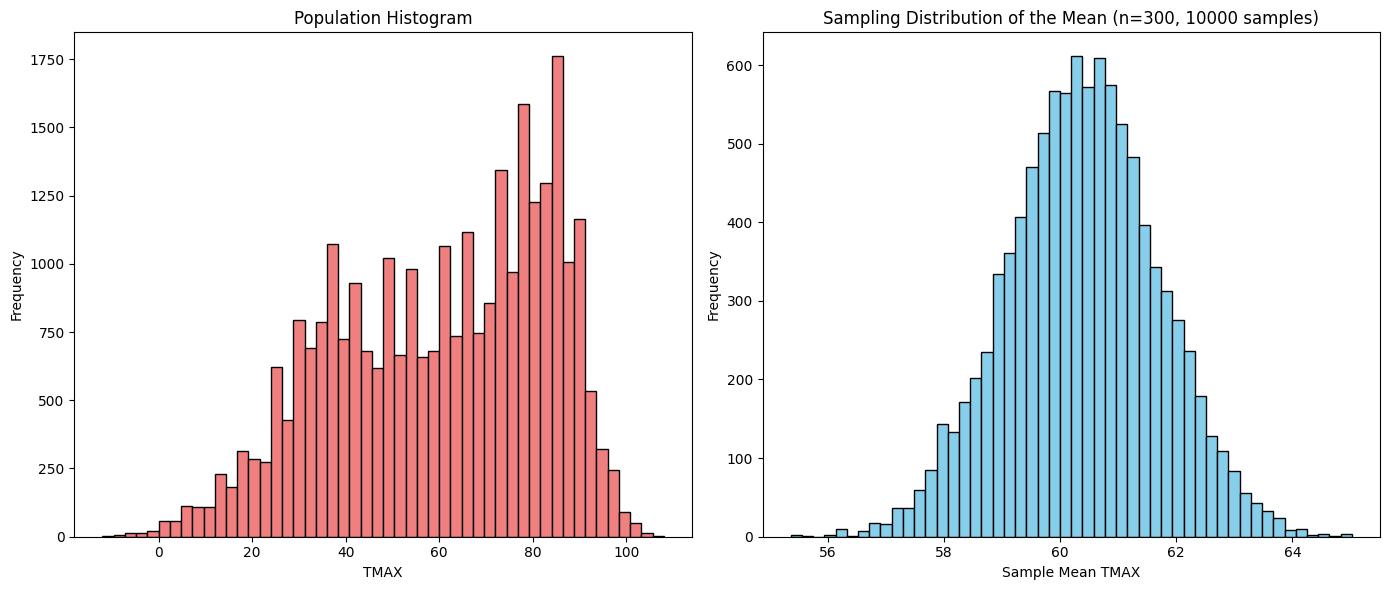

average mean of 10000 samples: 60.3716
average sigma of samples: 22.7348
mean of population: 60.3739
sigma of pop: 22.7504
average standard error of sample: 1.6076


In [112]:
import statistics
import math
import matplotlib.pyplot as plt

df_2 = pd.read_csv('DSM_IA_Weather.csv')
df_3 = df_2[['DATE','TMAX']]

population_mean = df_3.TMAX.mean()
population_sigma = df_3.TMAX.std()

sample_means = []
sample_sigmas = []
standard_errors = []

n_samples = 10000
sample_size = 300

for i in range(n_samples):
    df_sample = df_3.sample(n=sample_size)
    sample_means.append(df_sample.TMAX.mean())
    sample_sigmas.append(df.TMAX.std())
    standard_errors.append(df.TMAX.std()/math.sqrt(200))

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Population histogram
axes[0].hist(df_3.TMAX, bins=50, color='lightcoral', edgecolor='black')
axes[0].set_title("Population Histogram")
axes[0].set_xlabel("TMAX")
axes[0].set_ylabel("Frequency")

# Sampling distribution of the mean
axes[1].hist(sample_means, bins=50, color='skyblue', edgecolor='black')
axes[1].set_title(f"Sampling Distribution of the Mean (n={sample_size}, {n_samples} samples)")
axes[1].set_xlabel("Sample Mean TMAX")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"average mean of 10000 samples: {mean_of_samples:.4f}")
print(f"average sigma of samples: {mean_of_sample_sigmas:.4f}")
print(f"mean of population: {population_mean:.4f}")
print(f"sigma of pop: {population_sigma:.4f}")
print(f"average standard error of sample: {mean_of_standard_errors:.4f}")

#### This is a demonstration of the Central Limit Theorem. The population temperatures form a bimodal distribution due to winter and summer seasons. However, when we take 10,000 random samples of size 𝑛=300, the distribution of the sample means becomes approximately normal, even though the underlying population is bimodal.